In [1]:
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt


from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)
# Uncomment this if you want to try the code on your google drive space
#from google.colab import drive

import warnings

warnings.filterwarnings('ignore')
print('Libraries imported successfully')

Libraries imported successfully


In [2]:
GITHUB_BASE_URL = "https://raw.githubusercontent.com/Leonardo-Cortez/credit_risk_project_loan_default/main/Credit_Risk_Project"

# Helper function to download binary and text files from GitHub
def download_github_file(file_name, target_url):
    if not os.path.exists(file_name):
        print(f"Downloading {file_name} from GitHub...")
        try:
            response = requests.get(target_url)
            response.raise_for_status() # Raises an error for invalid responses (e.g., 404)
            with open(file_name, 'wb') as f:
                f.write(response.content)
            print(f"{file_name} downloaded successfully.")
        except Exception as e:
            print(f"Error: Could not download {file_name}. Details: {e}")
    else:
        print(f"{file_name} already exists locally.")

# Download and extract the heavy ZIP file from 'data/processed/'
zip_name = "X_train_processed.zip"
zip_url = GITHUB_BASE_URL + "/data/processed/" + zip_name
download_github_file(zip_name, zip_url)

# Extracting the ZIP archive automatically into Colab's workspace
if os.path.exists(zip_name):
    print(f"Extracting {zip_name}...")
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(".") # Extracts directly to the local folder
    print("Extraction completed.")

# 4. Download individual data assets from 'data/processed/'
data_files = [
    "X_test_processed.npy",
    "y_train.csv",
    "y_test.csv",
    "feature_names.csv"
]

for file in data_files:
    file_url = GITHUB_BASE_URL + "/data/processed/" + file
    download_github_file(file, file_url)

# Download the preprocessor asset from 'models/'
preprocessor_file = "preprocessor.pkl"
preprocessor_url = GITHUB_BASE_URL + "/models/" + preprocessor_file
download_github_file(preprocessor_file, preprocessor_url)


print("\n" + "="*50 + "\nLoading objects into workspace memory...\n" + "="*50)

# Load preprocessor, processed data, labels, and variable names into local variables
try:
    # Loading the Scikit-Learn preprocessor object (.pkl)
    preprocessor = joblib.load("preprocessor.pkl")

    # Loading NumPy array matrices (.npy)
    X_train = np.load("X_train_processed.npy")
    X_test = np.load("X_test_processed.npy")

    # Loading ground truth labels and features target DataFrames (.csv)
    y_train = pd.read_csv("y_train.csv").squeeze()
    y_test = pd.read_csv("y_test.csv").squeeze()
    feature_names = pd.read_csv("feature_names.csv")

    print("Dataset processed, labels, models, and variable names loaded successfully!")

except FileNotFoundError as e:
    print(f"Error: Required file was not found in the local environment: {e}")
except Exception as e:
    print(f"Error loading the data objects: {e}")

X_train_processed.zip downloaded successfully.
Extracting X_train_processed.zip...
Extraction completed.
X_test_processed.npy downloaded successfully.
y_train.csv downloaded successfully.
y_test.csv downloaded successfully.
feature_names.csv downloaded successfully.
preprocessor.pkl downloaded successfully.

Loading objects into workspace memory...
Dataset processed, labels, models, and variable names loaded successfully!


In [ ]:
# Google drive connection
# Uncomment this if you want to try the code on your google drive space
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading preprocessor, data processed, labels and variable names (from Notebook 03)
# Uncomment this if you want to try the code on your google drive space
"""
preprocessor = joblib.load(
    "/content/drive/MyDrive/Credit_Risk_Project/models/preprocessor.pkl"
)

X_train = np.load(
    "/content/drive/MyDrive/Credit_Risk_Project/data/processed/X_train_processed.npy"
)

X_test = np.load(
    "/content/drive/MyDrive/Credit_Risk_Project/data/processed/X_test_processed.npy"
)

y_train = pd.read_csv(
    "/content/drive/MyDrive/Credit_Risk_Project/data/processed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "/content/drive/MyDrive/Credit_Risk_Project/data/processed/y_test.csv"
).squeeze()

feature_names = pd.read_csv(
    "/content/drive/MyDrive/Credit_Risk_Project/data/processed/feature_names.csv"
)
"""

In [3]:
# Training again best model of Notebook 04

logistic_balanced_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

logistic_balanced_model.fit(
    X_train,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [4]:
best_model = logistic_balanced_model

In [5]:
# Getting probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

In [6]:
# Show probabilities
y_prob[:10]

array([0.18625729, 0.1401666 , 0.37832424, 0.56920764, 0.40762472,
       0.06906911, 0.80516978, 0.36752196, 0.79630316, 0.59399148])

In [7]:
# Saving Logistic regresion balanced
joblib.dump(logistic_balanced_model, "logistic_balanced_model.pkl")

['logistic_balanced_model.pkl']

In [ ]:
# Saving Logistic regresion balanced
# Uncomment this if you want to try the code on your google drive space
#joblib.dump(logistic_balanced_model, "/content/drive/MyDrive/Credit_Risk_Project/models/logistic_balanced_model.pkl")

['/content/drive/MyDrive/Credit_Risk_Project/models/logistic_balanced_model.pkl']

In [8]:
# Creating a list of thresholds

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

In [9]:
threshold_results = []

In [10]:
for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    threshold_results.append(
        [
            threshold,
            accuracy,
            precision,
            recall,
            f1
        ]
    )

In [11]:
threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

In [12]:
threshold_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.143587,0.118999,0.995448,0.212584
1,0.15,0.194341,0.124888,0.988366,0.221756
2,0.20,0.258782,0.132655,0.971843,0.233445
3,0.25,0.328549,0.141955,0.947901,0.246931
4,0.30,0.401664,0.152940,0.914854,0.262069
5,0.35,0.474819,0.165653,0.872534,0.278443
6,0.40,0.547171,0.181397,0.825325,0.297424
7,0.45,0.614823,0.200026,0.772382,0.317761
8,0.50,0.676346,0.219541,0.699376,0.334179
9,0.55,0.731565,0.245218,0.631091,0.353197


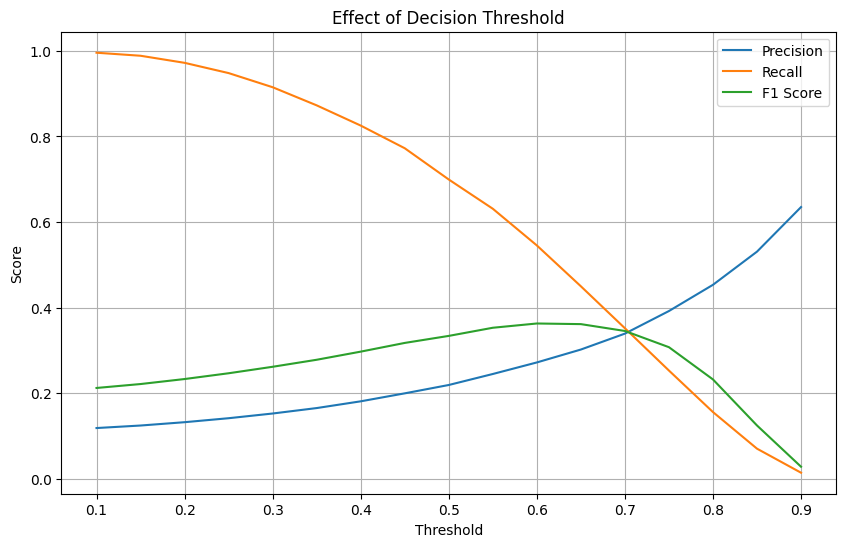

In [13]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Effect of Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()

**ROC Curve and Precision-Recall Curve**

In [14]:
# Probabilities
y_prob = logistic_balanced_model.predict_proba(X_test)[:, 1]

In [15]:
# Calculating curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

In [16]:
# Calculating area
roc_auc = auc(
    fpr,
    tpr
)

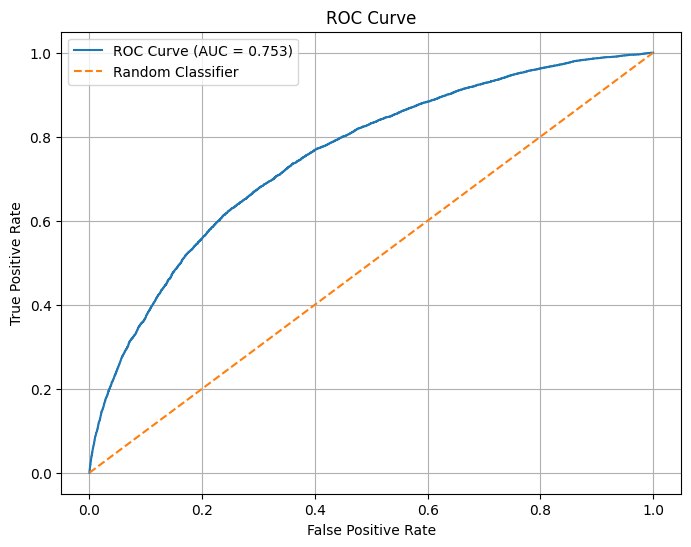

In [17]:
# Graph
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Calculating Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

In [19]:
# Calculating average precision (AP)
average_precision = average_precision_score(
    y_test,
    y_prob
)

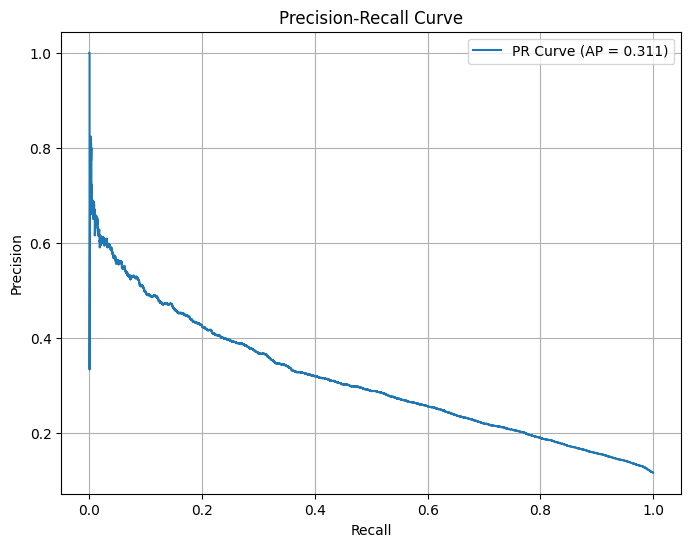

In [20]:
# Plotting precision-recall curve

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f"PR Curve (AP = {average_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()